In [62]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

In [63]:
X = 6 * np.random.rand(200, 1) - 3
y = 0.8 * X**2 + 0.9 * X + 2 + np.random.randn(200, 1)

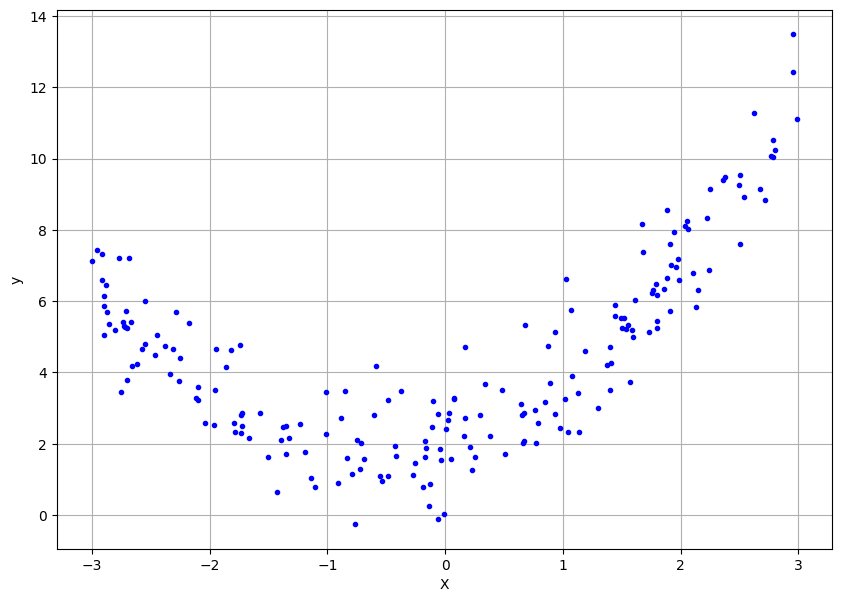

In [64]:
plt.figure(figsize=(10, 7))
plt.plot(X, y,'b.')
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.show()

In [65]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

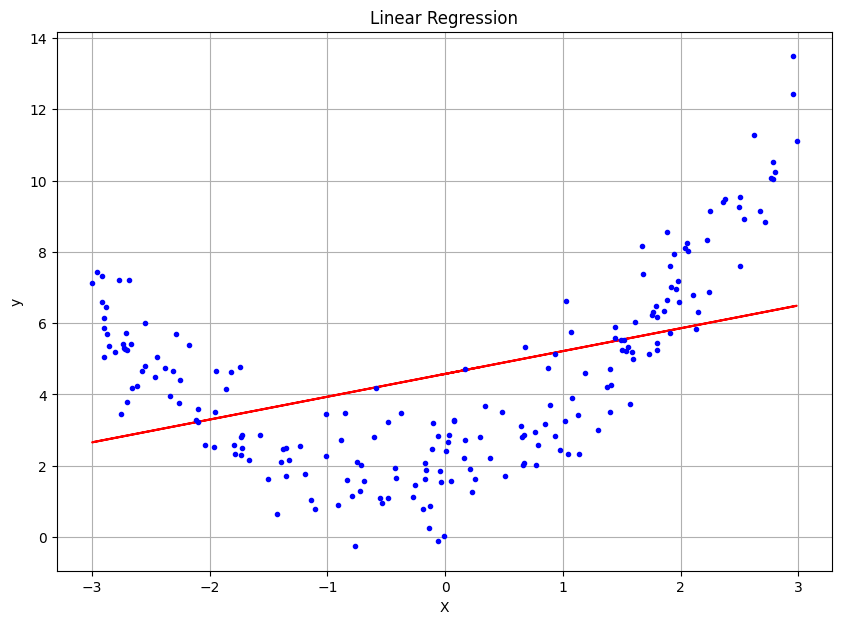

R2 score =  0.1354247501363195
RMSE =  2.336197090917722


In [66]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)
y_pred = lr.predict(X_test)
plt.figure(figsize=(10, 7))
plt.plot(X_train,lr.predict(X_train),color='r')
plt.plot(X, y, "b.")
plt.title("Linear Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.grid(True)
plt.show()
print("R2 score = ",r2_score(y_test,y_pred))
print("RMSE = ",mean_squared_error(y_test,y_pred)**0.5)

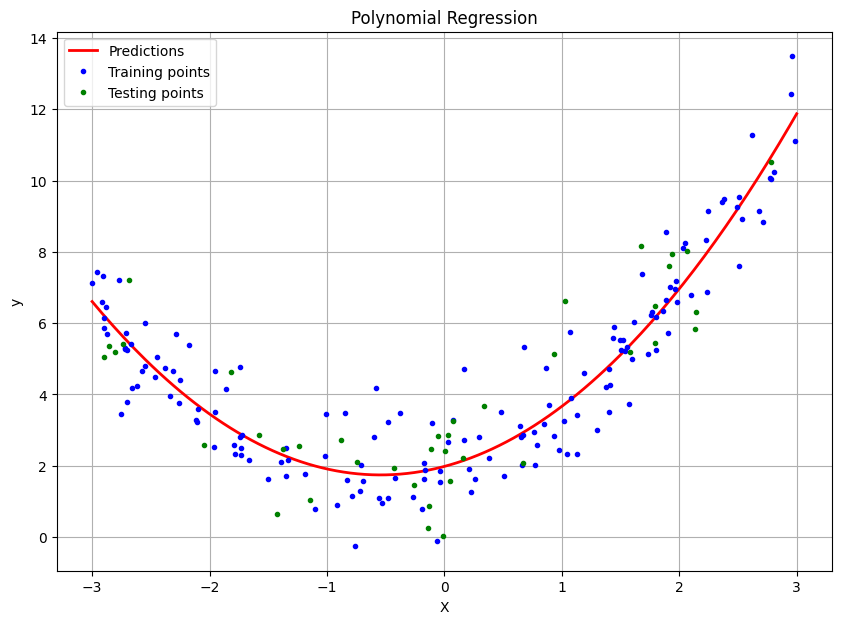

R2 score =  0.7899173222591305
RMSE =  1.1516040977333502


In [67]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(degree=2)
X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)
lr = LinearRegression()
lr.fit(X_train_trans,y_train)
y_pred = lr.predict(X_test_trans)
X_new=np.linspace(-3, 3, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = lr.predict(X_new_poly)
plt.figure(figsize=(10, 7))
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.title("Polynomial Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
print("R2 score = ",r2_score(y_test,y_pred))
print("RMSE = ",mean_squared_error(y_test,y_pred)**0.5)


--- Ridge Regression with alpha = 0.1 ---
R2 score = 0.7899
RMSE = 1.1516

--- Ridge Regression with alpha = 1.0 ---
R2 score = 0.7899
RMSE = 1.1517

--- Ridge Regression with alpha = 10.0 ---
R2 score = 0.7894
RMSE = 1.1530

--- Ridge Regression with alpha = 100.0 ---
R2 score = 0.7739
RMSE = 1.1946

--- Best Ridge Regression Model (alpha = 0.1) ---


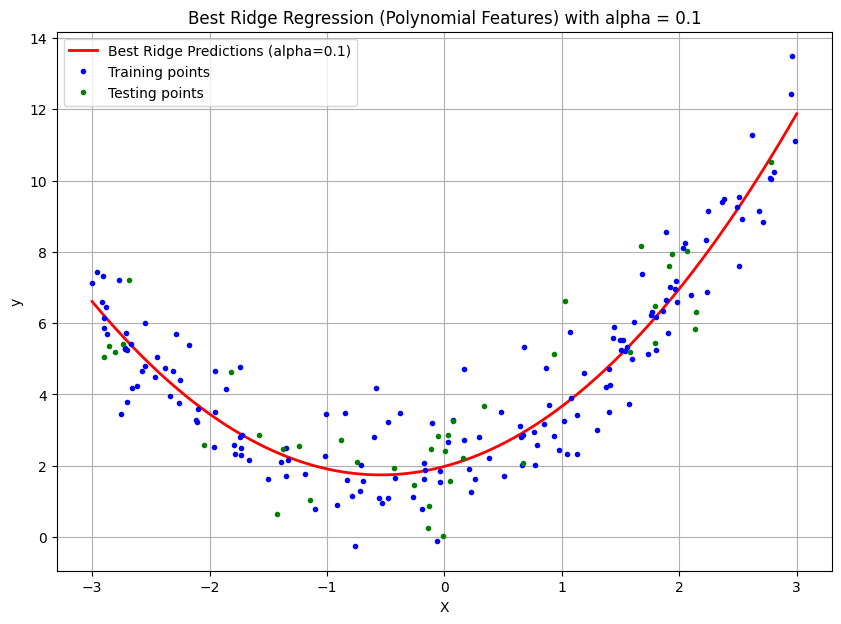

Best R2 score = 0.7899
Best RMSE = 1.1516


In [68]:
from sklearn.linear_model import Ridge
alphas = [0.1, 1.0, 10.0, 100.0]
best_rmse = float('inf')
best_alpha = None
best_r2 = None
best_y_new_ridge = None
best_model = None
for alpha in alphas:
    ridge_reg_tuned = Ridge(alpha=alpha)
    ridge_reg_tuned.fit(X_train_trans, y_train)
    y_pred_ridge_tuned = ridge_reg_tuned.predict(X_test_trans)
    r2 = r2_score(y_test, y_pred_ridge_tuned)
    rmse = mean_squared_error(y_test, y_pred_ridge_tuned)**0.5
    print(f"\n--- Ridge Regression with alpha = {alpha} ---")
    print(f"R2 score = {r2:.4f}")
    print(f"RMSE = {rmse:.4f}")
    if rmse < best_rmse:
        best_rmse = rmse
        best_alpha = alpha
        best_r2 = r2
        best_model = ridge_reg_tuned
        best_y_new_ridge = ridge_reg_tuned.predict(X_new_poly)
print(f"\n--- Best Ridge Regression Model (alpha = {best_alpha}) ---")
plt.figure(figsize=(10, 7))
plt.plot(X_new, best_y_new_ridge, "r-", linewidth=2, label=f"Best Ridge Predictions (alpha={best_alpha})")
plt.plot(X_train, y_train, "b.", label='Training points')
plt.plot(X_test, y_test, "g.", label='Testing points')
plt.title(f"Best Ridge Regression (Polynomial Features) with alpha = {best_alpha}")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
print(f"Best R2 score = {best_r2:.4f}")
print(f"Best RMSE = {best_rmse:.4f}")


--- Lasso Regression with alpha = 0.001 ---
R2 score = 0.7899
RMSE = 1.1516

--- Lasso Regression with alpha = 0.01 ---
R2 score = 0.7899
RMSE = 1.1517

--- Lasso Regression with alpha = 0.1 ---
R2 score = 0.7888
RMSE = 1.1548

--- Lasso Regression with alpha = 1.0 ---
R2 score = 0.7158
RMSE = 1.3395

--- Lasso Regression with alpha = 10.0 ---
R2 score = -0.0424
RMSE = 2.5652

--- Best Lasso Regression Model (alpha = 0.001) ---


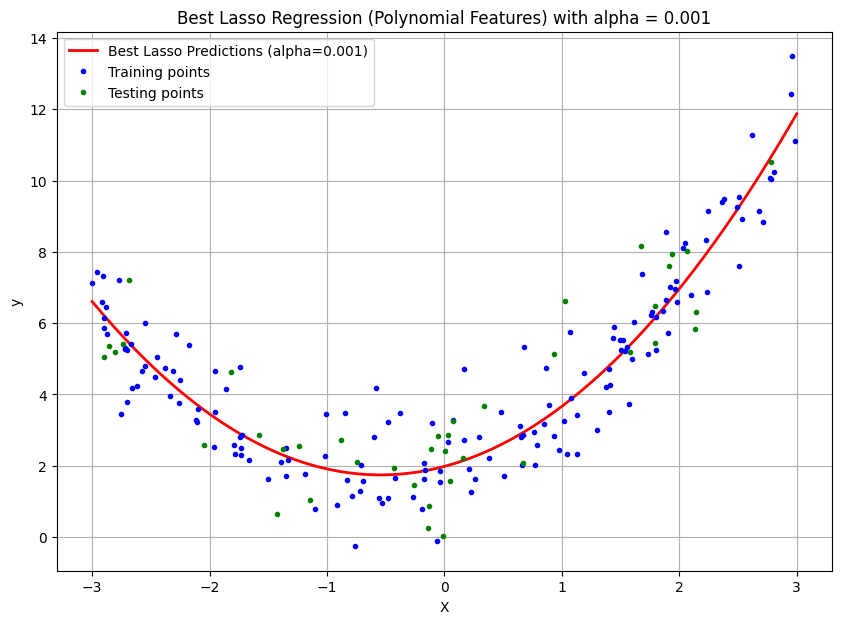

Best Lasso R2 score = 0.7899
Best Lasso RMSE = 1.1516


In [69]:
from sklearn.linear_model import Lasso
alphas = [0.001, 0.01, 0.1, 1.0, 10.0]
best_rmse_lasso = float('inf')
best_alpha_lasso = None
best_r2_lasso = None
best_y_new_lasso = None
best_model_lasso = None
for alpha in alphas:
    lasso_reg_tuned = Lasso(alpha=alpha, max_iter=10000)
    lasso_reg_tuned.fit(X_train_trans, y_train)
    y_pred_lasso_tuned = lasso_reg_tuned.predict(X_test_trans)
    r2 = r2_score(y_test, y_pred_lasso_tuned)
    rmse = mean_squared_error(y_test, y_pred_lasso_tuned)**0.5
    print(f"\n--- Lasso Regression with alpha = {alpha} ---")
    print(f"R2 score = {r2:.4f}")
    print(f"RMSE = {rmse:.4f}")
    if rmse < best_rmse_lasso:
        best_rmse_lasso = rmse
        best_alpha_lasso = alpha
        best_r2_lasso = r2
        best_model_lasso = lasso_reg_tuned
        best_y_new_lasso = lasso_reg_tuned.predict(X_new_poly)
print(f"\n--- Best Lasso Regression Model (alpha = {best_alpha_lasso}) ---")
plt.figure(figsize=(10, 7))
plt.plot(X_new, best_y_new_lasso, "r-", linewidth=2, label=f"Best Lasso Predictions (alpha={best_alpha_lasso})")
plt.plot(X_train, y_train, "b.", label='Training points')
plt.plot(X_test, y_test, "g.", label='Testing points')
plt.title(f"Best Lasso Regression (Polynomial Features) with alpha = {best_alpha_lasso}")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
print(f"Best Lasso R2 score = {best_r2_lasso:.4f}")
print(f"Best Lasso RMSE = {best_rmse_lasso:.4f}")


--- ElasticNet Regression with alpha = 0.001, l1_ratio = 0.1 ---
R2 score = 0.7899
RMSE = 1.1516

--- ElasticNet Regression with alpha = 0.001, l1_ratio = 0.5 ---
R2 score = 0.7899
RMSE = 1.1516

--- ElasticNet Regression with alpha = 0.001, l1_ratio = 0.9 ---
R2 score = 0.7899
RMSE = 1.1516

--- ElasticNet Regression with alpha = 0.01, l1_ratio = 0.1 ---
R2 score = 0.7899
RMSE = 1.1518

--- ElasticNet Regression with alpha = 0.01, l1_ratio = 0.5 ---
R2 score = 0.7899
RMSE = 1.1518

--- ElasticNet Regression with alpha = 0.01, l1_ratio = 0.9 ---
R2 score = 0.7899
RMSE = 1.1517

--- ElasticNet Regression with alpha = 0.1, l1_ratio = 0.1 ---
R2 score = 0.7889
RMSE = 1.1543

--- ElasticNet Regression with alpha = 0.1, l1_ratio = 0.5 ---
R2 score = 0.7889
RMSE = 1.1545

--- ElasticNet Regression with alpha = 0.1, l1_ratio = 0.9 ---
R2 score = 0.7888
RMSE = 1.1547

--- ElasticNet Regression with alpha = 1.0, l1_ratio = 0.1 ---
R2 score = 0.7548
RMSE = 1.2442

--- ElasticNet Regression with

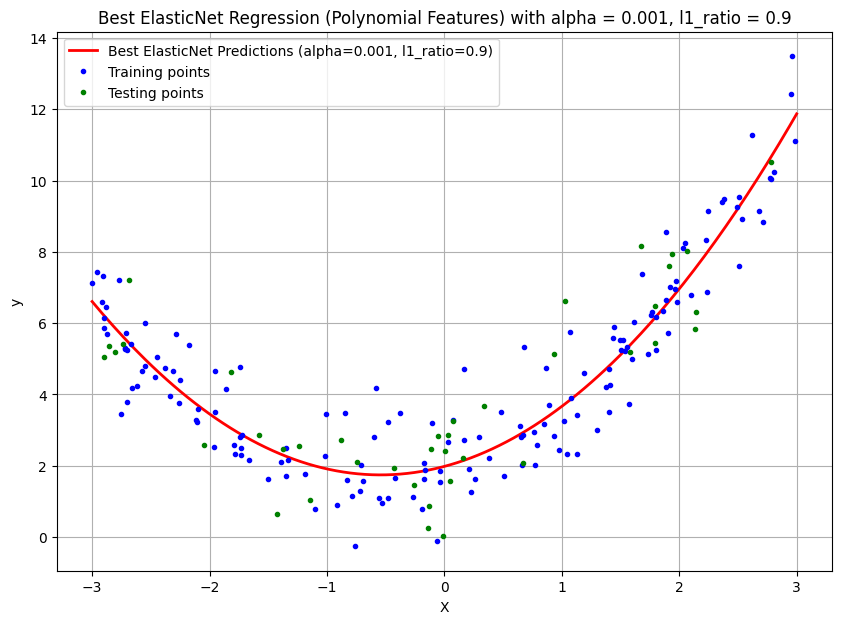

Best ElasticNet R2 score = 0.7899
Best ElasticNet RMSE = 1.1516


In [70]:
from sklearn.linear_model import ElasticNet
alphas_elastic = [0.001, 0.01, 0.1, 1.0]
l1_ratios_elastic = [0.1, 0.5, 0.9]
best_rmse_elastic = float('inf')
best_alpha_elastic = None
best_l1_ratio_elastic = None
best_r2_elastic = None
best_y_new_elastic = None
best_model_elastic = None
for alpha in alphas_elastic:
    for l1_ratio in l1_ratios_elastic:
        elastic_net_tuned = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=10000)
        elastic_net_tuned.fit(X_train_trans, y_train)
        y_pred_elastic_tuned = elastic_net_tuned.predict(X_test_trans)
        r2 = r2_score(y_test, y_pred_elastic_tuned)
        rmse = mean_squared_error(y_test, y_pred_elastic_tuned)**0.5
        print(f"\n--- ElasticNet Regression with alpha = {alpha}, l1_ratio = {l1_ratio} ---")
        print(f"R2 score = {r2:.4f}")
        print(f"RMSE = {rmse:.4f}")
        if rmse < best_rmse_elastic:
            best_rmse_elastic = rmse
            best_alpha_elastic = alpha
            best_l1_ratio_elastic = l1_ratio
            best_r2_elastic = r2
            best_model_elastic = elastic_net_tuned
            best_y_new_elastic = elastic_net_tuned.predict(X_new_poly)
print(f"\n--- Best ElasticNet Regression Model (alpha = {best_alpha_elastic}, l1_ratio = {best_l1_ratio_elastic}) ---")
plt.figure(figsize=(10, 7))
plt.plot(X_new, best_y_new_elastic, "r-", linewidth=2, label=f"Best ElasticNet Predictions (alpha={best_alpha_elastic}, l1_ratio={best_l1_ratio_elastic})")
plt.plot(X_train, y_train, "b.", label='Training points')
plt.plot(X_test, y_test, "g.", label='Testing points')
plt.title(f"Best ElasticNet Regression (Polynomial Features) with alpha = {best_alpha_elastic}, l1_ratio = {best_l1_ratio_elastic}")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
print(f"Best ElasticNet R2 score = {best_r2_elastic:.4f}")
print(f"Best ElasticNet RMSE = {best_rmse_elastic:.4f}")

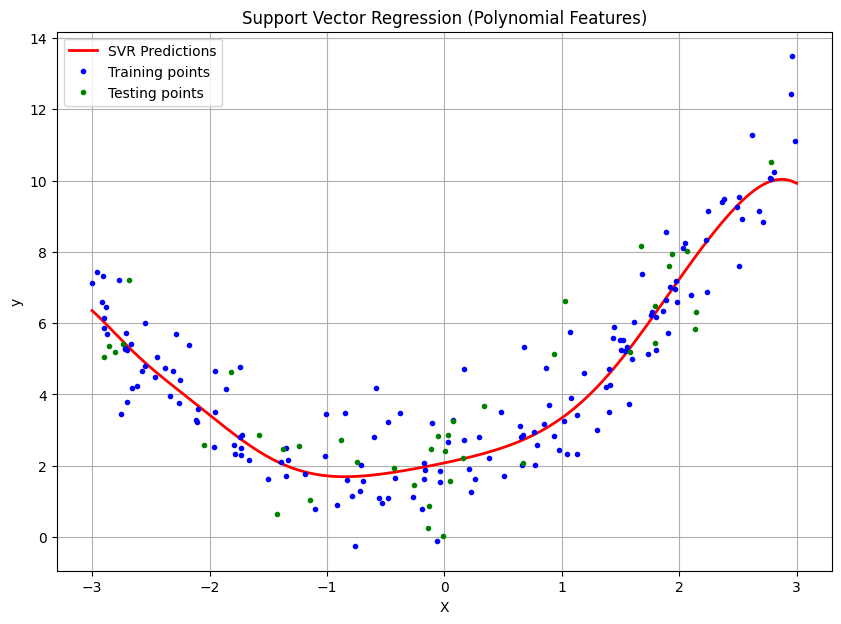

R2 score (SVR) =  0.773628393088007
RMSE (SVR) =  1.195415977708582


In [71]:
from sklearn.svm import SVR
svr_reg = SVR(kernel='rbf')
svr_reg.fit(X_train_trans, y_train.ravel())
y_pred_svr = svr_reg.predict(X_test_trans)
y_new_svr = svr_reg.predict(X_new_poly)
plt.figure(figsize=(10, 7))
plt.plot(X_new, y_new_svr, "r-", linewidth=2, label="SVR Predictions")
plt.plot(X_train, y_train, "b.", label='Training points')
plt.plot(X_test, y_test, "g.", label='Testing points')
plt.title("Support Vector Regression (Polynomial Features)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
print("R2 score (SVR) = ", r2_score(y_test, y_pred_svr))
print("RMSE (SVR) = ", mean_squared_error(y_test, y_pred_svr)**0.5)

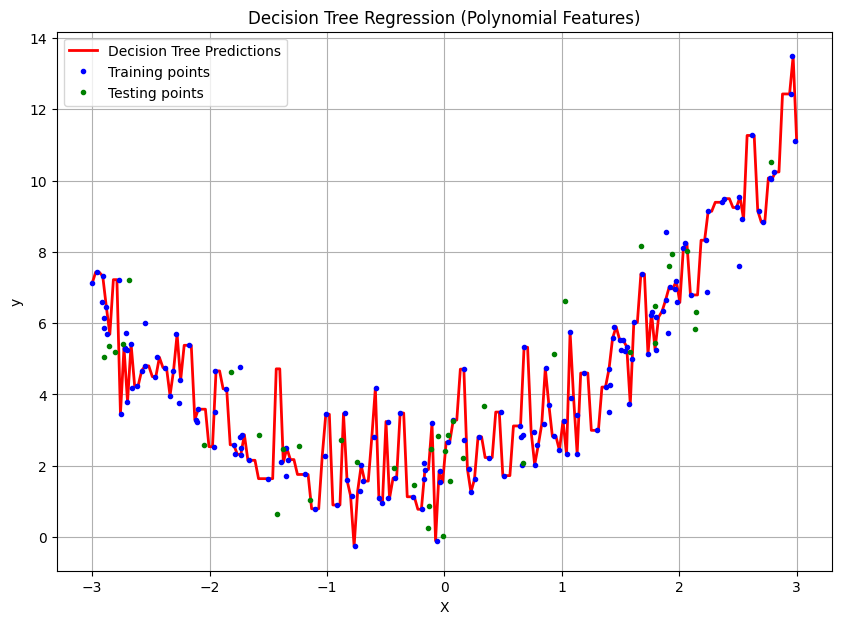

R2 score (Decision Tree) =  0.5916771635214786
RMSE (Decision Tree) =  1.6054985370917407


In [72]:
from sklearn.tree import DecisionTreeRegressor
dtree_reg = DecisionTreeRegressor(random_state=42)
dtree_reg.fit(X_train_trans, y_train)
y_pred_dtree = dtree_reg.predict(X_test_trans)
y_new_dtree = dtree_reg.predict(X_new_poly)
plt.figure(figsize=(10, 7))
plt.plot(X_new, y_new_dtree, "r-", linewidth=2, label="Decision Tree Predictions")
plt.plot(X_train, y_train, "b.", label='Training points')
plt.plot(X_test, y_test, "g.", label='Testing points')
plt.title("Decision Tree Regression (Polynomial Features)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
print("R2 score (Decision Tree) = ", r2_score(y_test, y_pred_dtree))
print("RMSE (Decision Tree) = ", mean_squared_error(y_test, y_pred_dtree)**0.5)

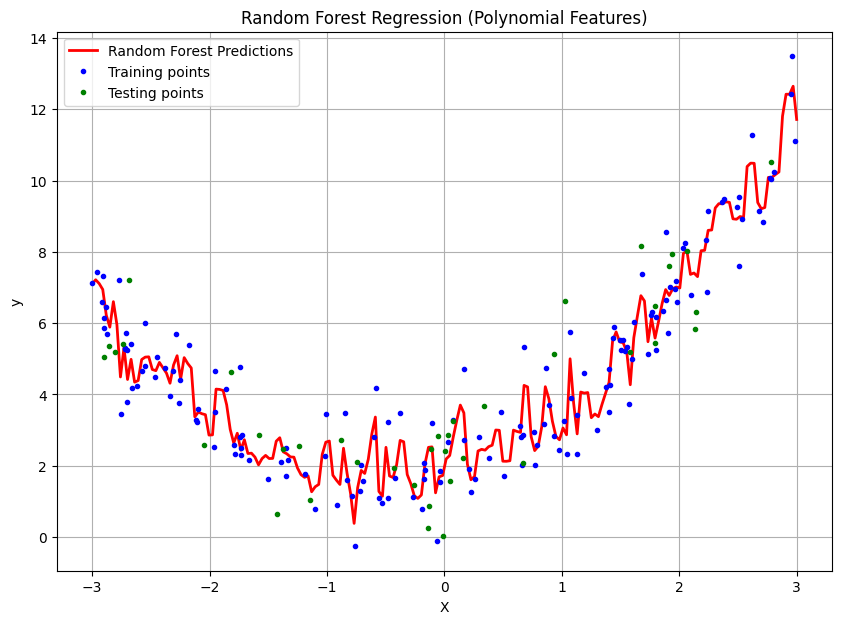

R2 score (Random Forest) =  0.7094552930655571
RMSE (Random Forest) =  1.354299017403476


In [73]:
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_trans, y_train.ravel())
y_pred_rf = rf_reg.predict(X_test_trans)
y_new_rf = rf_reg.predict(X_new_poly)
plt.figure(figsize=(10, 7))
plt.plot(X_new, y_new_rf, "r-", linewidth=2, label="Random Forest Predictions")
plt.plot(X_train, y_train, "b.", label='Training points')
plt.plot(X_test, y_test, "g.", label='Testing points')
plt.title("Random Forest Regression (Polynomial Features)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
print("R2 score (Random Forest) = ", r2_score(y_test, y_pred_rf))
print("RMSE (Random Forest) = ", mean_squared_error(y_test, y_pred_rf)**0.5)

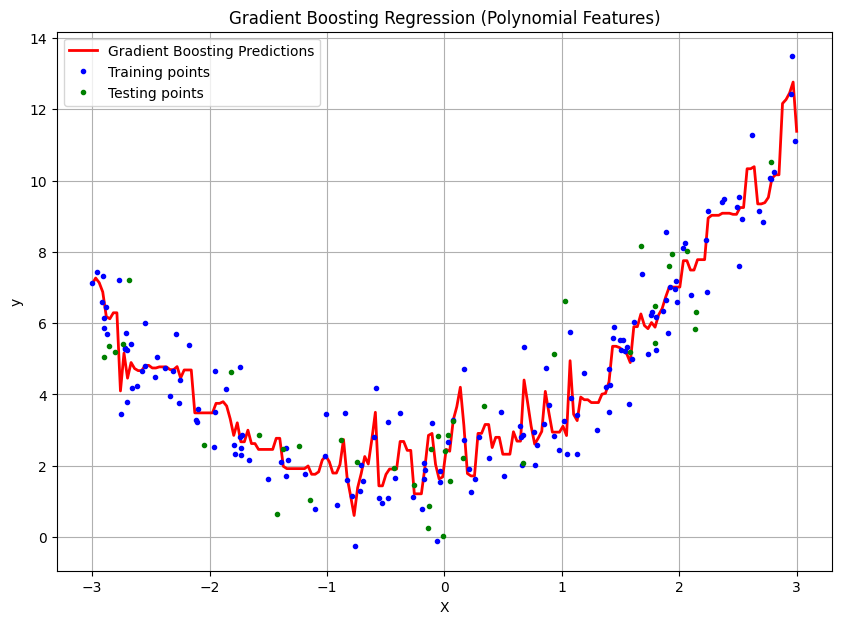

R2 score (Gradient Boosting) =  0.7059919877189966
RMSE (Gradient Boosting) =  1.3623467572339165


In [74]:
from sklearn.ensemble import GradientBoostingRegressor
gbr_reg = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
gbr_reg.fit(X_train_trans, y_train.ravel())
y_pred_gbr = gbr_reg.predict(X_test_trans)
y_new_gbr = gbr_reg.predict(X_new_poly)
plt.figure(figsize=(10, 7))
plt.plot(X_new, y_new_gbr, "r-", linewidth=2, label="Gradient Boosting Predictions")
plt.plot(X_train, y_train, "b.", label='Training points')
plt.plot(X_test, y_test, "g.", label='Testing points')
plt.title("Gradient Boosting Regression (Polynomial Features)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
print("R2 score (Gradient Boosting) = ", r2_score(y_test, y_pred_gbr))
print("RMSE (Gradient Boosting) = ", mean_squared_error(y_test, y_pred_gbr)**0.5)

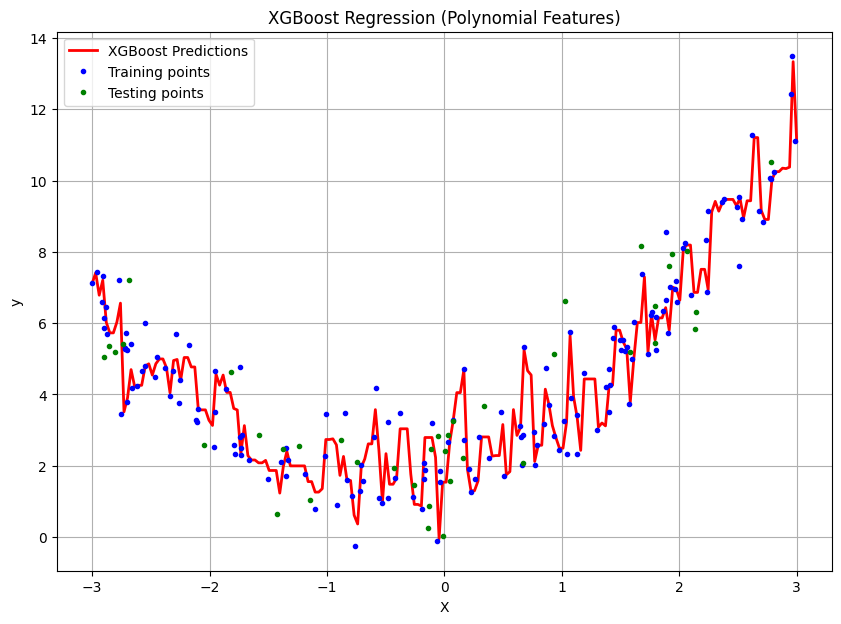

R2 score (XGBoost) =  0.6785662837793429
RMSE (XGBoost) =  1.4244715967854


In [75]:
import xgboost as xgb
xgb_reg = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
xgb_reg.fit(X_train_trans, y_train)
y_pred_xgb = xgb_reg.predict(X_test_trans)
y_new_xgb = xgb_reg.predict(X_new_poly)
plt.figure(figsize=(10, 7))
plt.plot(X_new, y_new_xgb, "r-", linewidth=2, label="XGBoost Predictions")
plt.plot(X_train, y_train, "b.", label='Training points')
plt.plot(X_test, y_test, "g.", label='Testing points')
plt.title("XGBoost Regression (Polynomial Features)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
print("R2 score (XGBoost) = ", r2_score(y_test, y_pred_xgb))
print("RMSE (XGBoost) = ", mean_squared_error(y_test, y_pred_xgb)**0.5)

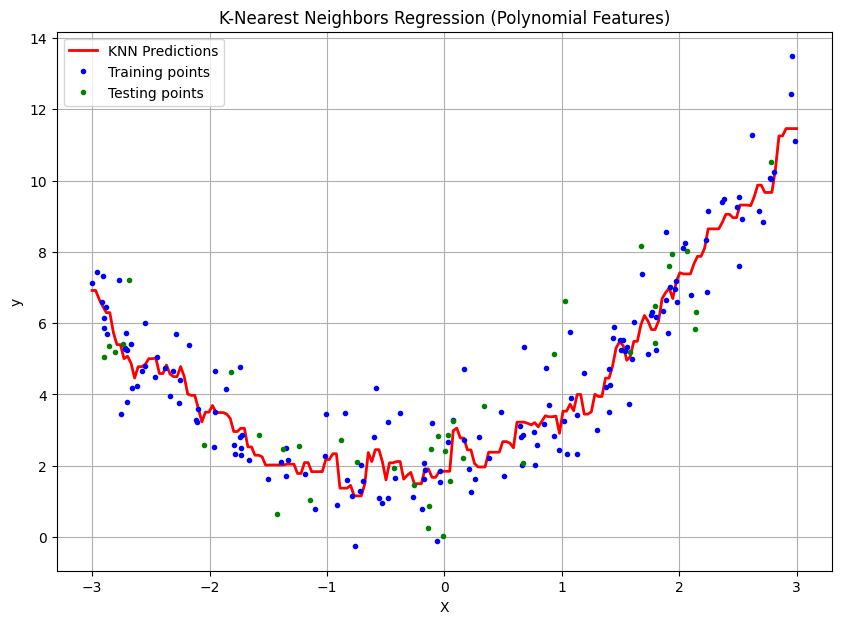

R2 score (KNN) =  0.7638709277295859
RMSE (KNN) =  1.220907635448284


In [76]:
from sklearn.neighbors import KNeighborsRegressor
knn_reg = KNeighborsRegressor(n_neighbors=5)
knn_reg.fit(X_train_trans, y_train)
y_pred_knn = knn_reg.predict(X_test_trans)
y_new_knn = knn_reg.predict(X_new_poly)
plt.figure(figsize=(10, 7))
plt.plot(X_new, y_new_knn, "r-", linewidth=2, label="KNN Predictions")
plt.plot(X_train, y_train, "b.", label='Training points')
plt.plot(X_test, y_test, "g.", label='Testing points')
plt.title("K-Nearest Neighbors Regression (Polynomial Features)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
print("R2 score (KNN) = ", r2_score(y_test, y_pred_knn))
print("RMSE (KNN) = ", mean_squared_error(y_test, y_pred_knn)**0.5)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000035 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 110
[LightGBM] [Info] Number of data points in the train set: 160, number of used features: 2
[LightGBM] [Info] Start training from score 4.545038
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


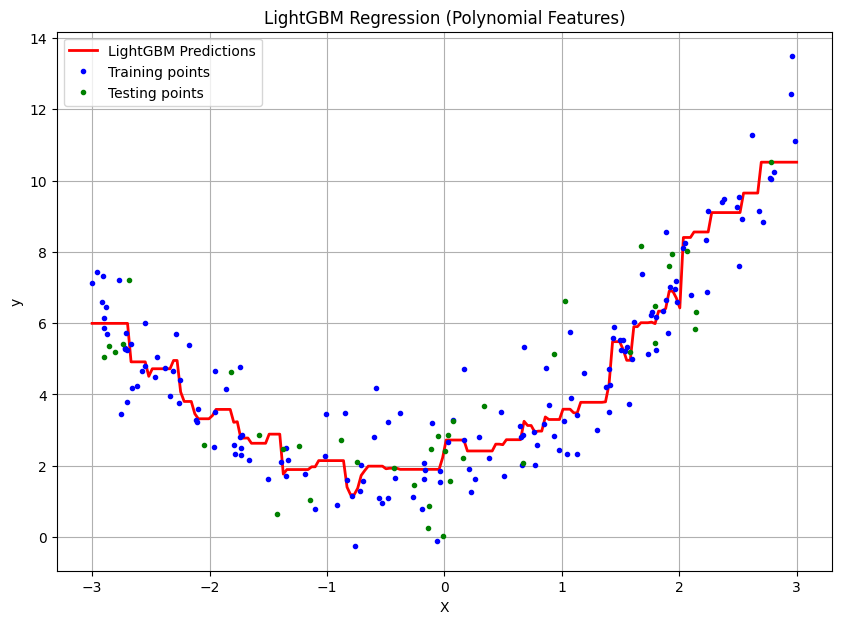

R2 score (LightGBM) =  0.7494865741918617
RMSE (LightGBM) =  1.2575451378116604


In [77]:
import lightgbm as lgb
lgbm_reg = lgb.LGBMRegressor(random_state=42)
lgbm_reg.fit(X_train_trans, y_train.ravel())
y_pred_lgbm = lgbm_reg.predict(X_test_trans)
y_new_lgbm = lgbm_reg.predict(X_new_poly)
plt.figure(figsize=(10, 7))
plt.plot(X_new, y_new_lgbm, "r-", linewidth=2, label="LightGBM Predictions")
plt.plot(X_train, y_train, "b.", label='Training points')
plt.plot(X_test, y_test, "g.", label='Testing points')
plt.title("LightGBM Regression (Polynomial Features)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
print("R2 score (LightGBM) = ", r2_score(y_test, y_pred_lgbm))
print("RMSE (LightGBM) = ", mean_squared_error(y_test, y_pred_lgbm)**0.5)

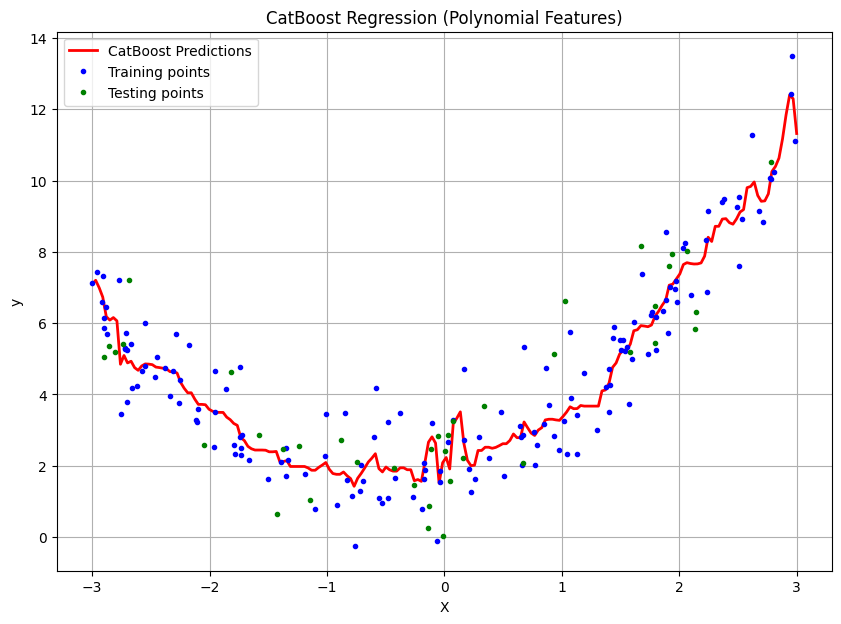

R2 score (CatBoost) =  0.7431199681462028
RMSE (CatBoost) =  1.273424650657429


In [78]:
from catboost import CatBoostRegressor
catb_reg = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=6, random_state=42, verbose=0) # verbose=0 to suppress output
catb_reg.fit(X_train_trans, y_train)
y_pred_catb = catb_reg.predict(X_test_trans)
y_new_catb = catb_reg.predict(X_new_poly)
plt.figure(figsize=(10, 7))
plt.plot(X_new, y_new_catb, "r-", linewidth=2, label="CatBoost Predictions")
plt.plot(X_train, y_train, "b.", label='Training points')
plt.plot(X_test, y_test, "g.", label='Testing points')
plt.title("CatBoost Regression (Polynomial Features)")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()
print("R2 score (CatBoost) = ", r2_score(y_test, y_pred_catb))
print("RMSE (CatBoost) = ", mean_squared_error(y_test, y_pred_catb)**0.5)